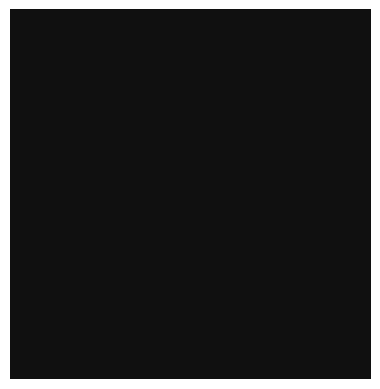

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

# Open TIFF
img = Image.open("Landcover-208906/L1C/Landcover-208906-1-sunZenithAngles.tiff")

# Display
plt.imshow(img)
plt.axis("off")
plt.show()


In [ ]:
import os
import requests

# ==== CONFIGURATION ====
API_KEY = ""  # Replace with your API key
OUTPUT_DIR = "satellite_images"
LATITUDE = 25.077309960527764
LONGITUDE = -77.4217480706209
ZOOM = 18             # Zoom level: 0 (world) -> 21+ (building)
IMAGE_SIZE = "640x640" # Max free tier size
SCALE = 1              # 1=normal, 2=high-res (counts as more pixels)

# ==== CREATE OUTPUT FOLDER ====
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==== BUILD REQUEST URL ====
url = (
    "https://maps.googleapis.com/maps/api/staticmap"
    f"?center={LATITUDE},{LONGITUDE}"
    f"&zoom={ZOOM}"
    f"&size={IMAGE_SIZE}"
    f"&scale={SCALE}"
    f"&maptype=satellite"
    f"&key={API_KEY}"
)

# ==== DOWNLOAD IMAGE ====
response = requests.get(url)

if response.status_code == 200:
    filename = os.path.join(OUTPUT_DIR, f"satellite_{LATITUDE}_{LONGITUDE}.jpg")
    with open(filename, "wb") as f:
        f.write(response.content)
    print(f"Saved satellite image: {filename}")
else:
    print(f"Error {response.status_code}: {response.text}")


Saved satellite image: satellite_images/satellite_25.077309960527764_-77.4217480706209.jpg


In [1]:
# download the full dataset
from huggingface_hub import snapshot_download
snapshot_download(repo_id="osv5m/osv5m", local_dir="datasets/osv5m", repo_type='dataset')


/home/fahimul/.conda/envs/CVGL/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 108 files: 100%|██████████| 108/108 [37:01<00:00, 20.57s/it] 


'/data/Research/Proj_worldDataset/datasets/osv5m'

In [2]:
import os
import zipfile
for root, dirs, files in os.walk("datasets/osv5m"):
    for file in files:
        if file.endswith(".zip"):
            with zipfile.ZipFile(os.path.join(root, file), 'r') as zip_ref:
                zip_ref.extractall(root)
                os.remove(os.path.join(root, file))
